In [5]:
""" n_chebII """

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
from math import pi, exp, cos, sin, log, sqrt, log10

Hp = .9
Hs = .1
wp = .5

eps = sqrt(Hs**2/(1-Hs**2))
aa = sqrt((1/eps**2)*(1/(1-Hp**2)))
bb = 1 / np.arccosh(1/wp)
n = np.arccosh(aa)*bb
print('n = ', n)

n =  2.901074190983487


alpha =  19.949874371066194
a =  5.986565427129609e-05  b =  1.0000000017919484


<>:40: SyntaxWarning: invalid escape sequence '\o'
<>:40: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_22188\2640936504.py:40: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')


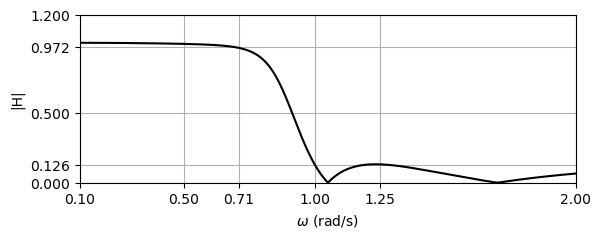

In [17]:
""" Example 8.4.1 """

alpha = 1/eps + sqrt(1 + 1/eps**2)
print('alpha = ',alpha)
a = 0.5*(alpha**(1/n)-alpha**(-1/n))
b = 0.5*(alpha**(1/n)+alpha**(-1/n))
print('a = ',a,' b = ',b)

theta = (180-36)*(pi/180)
d1 = [1, -2*a*cos(theta), (a**2)*cos(theta)**2 + (b**2)*sin(theta)**2]

theta = (180-72)*(pi/180)
d2 = [1, -2*a*cos(theta), (a**2)*cos(theta)**2 + (b**2)*sin(theta)**2]
K = .9*d1[2]*d2[2]

q1 = 0.144 + 1j*0.896
q1c = np.conjugate(q1)
d1 = [1, -np.real(q1+q1c), np.real(q1*q1c)]
q2 = -0.688 + 1j*0.996
q2c = np.conjugate(q2)
d2 = [1, -np.real(q2+q2c), np.real(q2*q2c)]
d3 = [1, 1.72]
d12 = np.convolve(d1,d2)
den = np.convolve(d12,d3)
n1 = [0,1,0,1.7**2]
n2 = [1,0,1.051**2]
K = d1[2]*d2[2]*d3[1]/(n1[3]*n2[2])
num = K*np.convolve(n1,n2)

w = np.linspace(.01,10,1000)
system = sig.lti(num, den)
w, Hmag, Hphase = sig.bode(system,n=1000)

plt.subplot(211)
plt.plot(w,10**(0.05*Hmag),'k')
plt.axis([.1, 2, 0, 1.2])
plt.xticks([.1, .5, .71, 1, 1.25, 2])
plt.yticks([0, 0.126, .5, .972, 1.2])
plt.grid(which='both')
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('|H|')
plt.show()